# Analise de Vacinas em Geral (SI-PNI/RNDS)

Panorama de todas as doencas/vacinas aplicadas na base bruta de janeiro/2026 (`data/vacinacao/raw/vacinacao_jan_2026.csv`, ~11,9 milhoes de doses), antes de recortar para sarampo. Ver [02-analise-exploratoria-vacinacao.ipynb](02-analise-exploratoria-vacinacao.ipynb) para a estrutura das colunas e [04-analise-vacina-sarampo.ipynb](04-analise-vacina-sarampo.ipynb) para o recorte de sarampo.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Paleta categorica validada (blue, orange, aqua, yellow, magenta, green, violet, red)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = "#2a78d6"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": TEXT_PRIMARY,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RAW_PATH = Path("..") / "data" / "vacinacao" / "raw" / "vacinacao_jan_2026.csv"

## 2. Contagem de doses por vacina/imunobiologico

In [2]:
contagem_vacinas = pd.Series(dtype="int64")
contagem_siglas = pd.Series(dtype="int64")
total_doses_raw = 0

for chunk in pd.read_csv(
    RAW_PATH,
    sep=";",
    encoding="latin-1",
    dtype=str,
    usecols=["ds_nome", "sg_imunobiologico"],
    chunksize=500_000,
    on_bad_lines="skip",
):
    contagem_vacinas = contagem_vacinas.add(chunk["ds_nome"].value_counts(), fill_value=0)
    contagem_siglas = contagem_siglas.add(chunk["sg_imunobiologico"].value_counts(), fill_value=0)
    total_doses_raw += len(chunk)

contagem_vacinas = contagem_vacinas.sort_values(ascending=False).astype(int)
contagem_siglas = contagem_siglas.sort_values(ascending=False).astype(int)

print(f"Total de doses na base completa (jan/2026): {total_doses_raw}")
print(f"N de vacinas/imunobiologicos distintos (ds_nome): {contagem_vacinas.shape[0]}")
contagem_vacinas

Total de doses na base completa (jan/2026): 11919438
N de vacinas/imunobiologicos distintos (ds_nome): 84


ds_nome
vacina influenza trivalente (fragmentada, inativada)                    1123793
vacina poliomelite 1, 2 e 3 (inativada)                                  998335
vacina adsorvida difteria e tétano adulto                                926809
vacina hepatite B (recombinante)                                         885537
vacina febre amarela (atenuada)                                          818036
                                                                         ...   
diluente para vacina sarampo, caxumba, rubéola e varicela (atenuada)          3
vacina pneumocócica 7-valente (conjugada)                                     2
vacina covid-19 (inativada)                                                   2
soro antidiftérico                                                            1
vacina rubéola (atenuada)                                                     1
Length: 84, dtype: int64

## 3. Top vacinas mais aplicadas

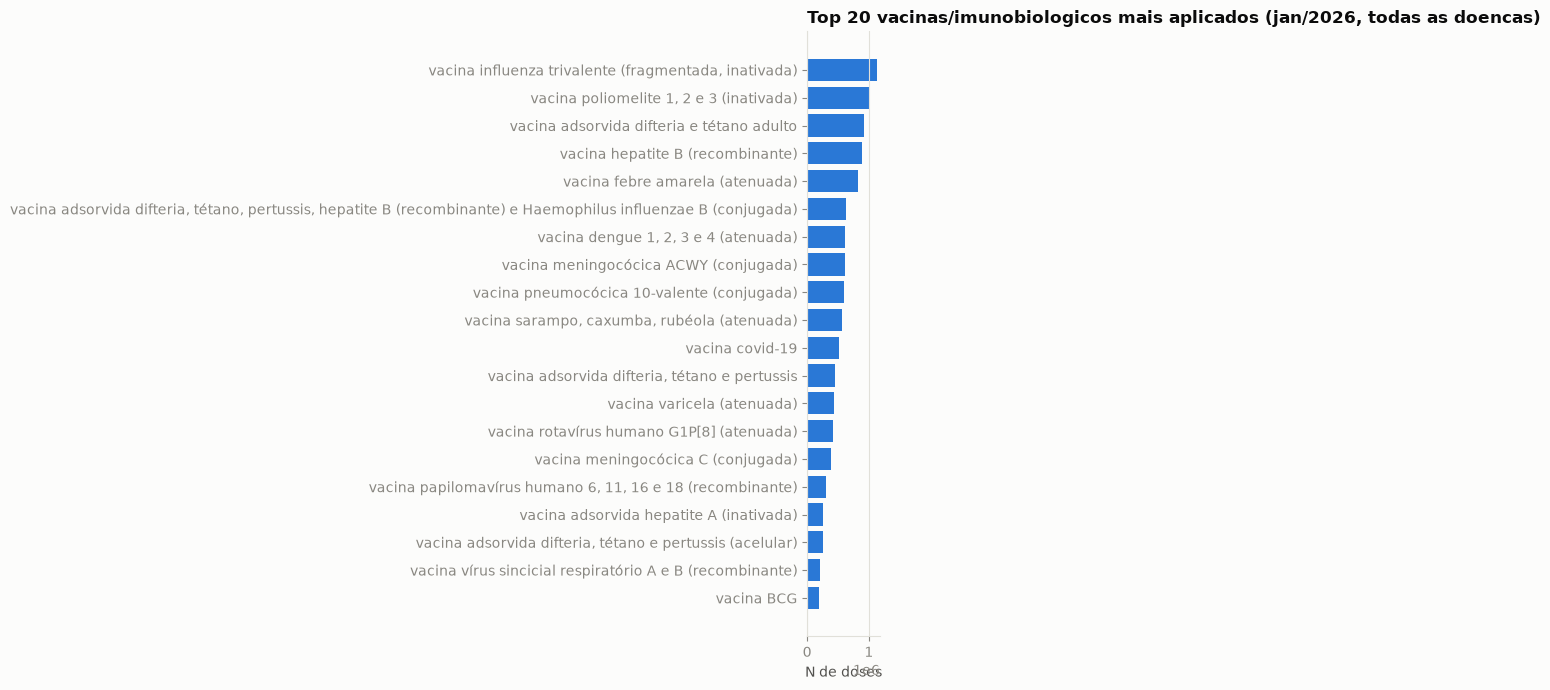

In [3]:
top_20_vacinas = contagem_vacinas.head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_20_vacinas.index, top_20_vacinas.values, color=SEQUENTIAL_BLUE)
ax.set_title("Top 20 vacinas/imunobiologicos mais aplicados (jan/2026, todas as doencas)", loc="left", fontweight="bold")
ax.set_xlabel("N de doses")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 4. Siglas de imunobiologico (sg_imunobiologico)

In [4]:
contagem_siglas.head(30)

sg_imunobiologico
INF3                    1123791
VIP                      998335
dT                       926809
HB                       885537
VFA                      818009
Penta                    626716
DNG                      619457
MenACWY                  609264
VPC10                    597540
SCR                      570617
DTP                      443115
VZ                       436407
ROTA                     411297
MenC                     392958
HPV4                     312868
COV-19 PFIZER-COMIRN     252520
dTpa                     251032
COVID-19 PFIZER-<5a      247105
HAinf                    236712
VVSR-Rec                 201020
BCG                      199329
VR                       126082
SCRV                     113362
VPC20                     89439
MenB                      71968
VPP23                     48972
Hexa acelular             48426
ROTA5                     34365
VHZR                      33439
HPV9                      33404
dtype: int64

## 5. Peso do sarampo no total

In [5]:
# Peso das vacinas de sarampo no total de doses aplicadas no mes
vacinas_sarampo_mask = contagem_vacinas.index.str.contains("sarampo", case=False, na=False)
doses_sarampo_raw = contagem_vacinas[vacinas_sarampo_mask].sum()

print(f"Vacinas com 'sarampo' na descricao: {contagem_vacinas[vacinas_sarampo_mask].index.tolist()}")
print(f"Doses de sarampo: {doses_sarampo_raw} ({doses_sarampo_raw / total_doses_raw * 100:.2f}% do total de {total_doses_raw})")

Vacinas com 'sarampo' na descricao: ['vacina sarampo, caxumba, rubéola (atenuada)', 'vacina sarampo, caxumba, rubéola e varicela (atenuada)', 'vacina sarampo, rubéola (atenuada)', 'diluente para vacina sarampo, caxumba, rubéola (atenuada)', 'vacina sarampo (atenuada)', 'diluente para vacina sarampo, caxumba, rubéola e varicela (atenuada)']
Doses de sarampo: 684469 (5.74% do total de 11919438)
